In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated

In [5]:
class ChatState(BaseModel):
    messages: Annotated[list, add_messages]

In [6]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [7]:
def chatBotNode(state: ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [8]:
memory = InMemorySaver()

In [9]:
graph = StateGraph(ChatState)
graph.add_node("chatBotNode", chatBotNode)

graph.add_edge(START, "chatBotNode")
graph.add_edge("chatBotNode", END)

graph = graph.compile(checkpointer=memory)

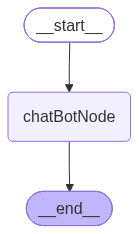

In [11]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [12]:
config = {"configurable": {"thread_id": "my_bot_1"}}
res = graph.invoke(
    {"messages": [{"role": "user", "content": "Hello, how are you? I am Anusha."}]},
    config
    )

In [15]:
res["messages"][-1].content

'Hello Anusha! I’m doing well—thanks for asking. How can I help you today?'

In [16]:
res = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?."}]},
    config
    )
res["messages"][-1].content

'Your name is Anusha.'